### 매뉴얼

본 프로젝트는 다양한 모델로 다양한 각도에서 분석을 시도한 프로젝트다. 따라서 데이터 수집 및 전처리는 대범주적으로는 3개의 방식(단순 선형 회귀, 다중 선형 회귀, 다항 선형 회귀) 모두 동일한 코드를 사용한다.

In [13]:
import os
import platform
import pandas as pd
import numpy as np
from IPython.display import display # 피쳐가 많은 해당 데이터를 좀 더 보기 쉽도록 하기 위해 불러온다.
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정(모든 OS에서 작동되도록)
if platform.system() == 'Darwin':       # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    plt.rc('font', family='Malgun Gothic')
else:                                   # Linux / Docker / Cloud
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


# 데이터 로드: ai_companion_dependency_dataset.csv
data= pd.read_csv('data/ai_companion_dependency_dataset.csv')


# 데이터 상위 5열 확인으로 컬럼(피쳐) 파악
print(data.head())

print(data.describe())


  user_id  age      gender   occupation_status education_level  income_level  \
0   U0001   21        Male  Employed Full-Time     High School  Lower-Middle   
1   U0002   34        Male             Student        Graduate  Upper-Middle   
2   U0003   43        Male  Employed Full-Time        Graduate           Low   
3   U0004   29  Non-binary  Employed Full-Time        Graduate           Low   
4   U0005   25      Female             Student        Graduate  Upper-Middle   

  relationship_status living_situation country_region ai_chatbot_platform  \
0   In a Relationship     With Partner  South America             ChatGPT   
1              Single            Alone  North America        Character.AI   
2              Single            Alone         Europe        Character.AI   
3              Single      With Family           Asia             ChatGPT   
4   In a Relationship   With Roommates  South America             ChatGPT   

   ... sleep_hours  sleep_quality_score  exercise_hours_

In [ ]:
# ===========================================================================================================

# 데이터 필터링-행 :: (청소년, 넓게는 청년층과 AI에 대한 심리적 문제가 대상이므로, 특정 연령대와 특정 이용목적만을 남긴다.)

# ===========================================================================================================

"""
age: 15세 ~ 24세 (청소년층 / 청년층)
primary_use_cases : Companion, Entertainment, Therapy-Substitute
"""
target_col = ['Companionship', 'Entertainment', 'Therapy-Substitute'] # 데이터를 분석할 행을 미리 지정

df_filtered = data[
    (data['age'] >= 15 ) & (data['age'] <= 24) &
    (data['primary_use_case'].isin(target_col)) # 미리 지정한 행, 15~24세만 남겨둔다.
].copy()
# ===========================================================================================================

# 데이터 필터링-열 :: 제외 피쳐 제거 후 분석 대상 피쳐만 선택

# ===========================================================================================================

"""
[제외 피쳐 목록]
user_id, gender, country_region, ai_chatbot_platform, prefers_ai_over_humans,
academic_or_work_performance_change, dependency_risk_label,
"""

"""
[첫 EDA 중 제외할 피쳐]
occupation_status(보류), relationship_status(초기 제외), living_situation(초기 제외)
"""

# 포함할 분석 대상 피쳐만 선택
selected_features = [
    # 인구통계 / 이용목적
    'age',
    'education_level',
    'income_level',
    'primary_use_case',
    # 일상 및 디지털 활동 시간
    'daily_ai_chat_hours',
    'human_social_interaction_hours',
    'social_media_hours_daily',
    'screen_time_total_hours',
    # 사회적 관계
    'number_of_close_friends',
    'real_relationship_satisfaction',
    # 생활 습관 및 수면
    'sleep_hours',
    'sleep_quality_score',
    'exercise_hours_weekly',
    # 심리적 척도
    'loneliness_score',
    'anxiety_score',
    'depression_score',
    'stress_score',
    'self_esteem_score',
    'therapy_attendance',
    # 종속 변수 (Target)
    'emotional_attachment_score'
]

# 최종 필터링 데이터프레임 생성
df= df_filtered[selected_features].reset_index(drop=True)


# 필터링된 데이터 확인
print(f"원본 데이터 크기: {data.shape}")
print(f"필터링 후 데이터 크기: {df.shape}")

print("\ndf.head()")
display(df.head())
print("\ndf.tail()")
display(df.tail())


원본 데이터 크기: (1000, 30)
필터링 후 데이터 크기: (196, 20)

df.head()


,age,education_level,income_level,primary_use_case,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,loneliness_score,anxiety_score,depression_score,stress_score,self_esteem_score,therapy_attendance,emotional_attachment_score
0,22,Graduate,Low,Entertainment,0.94,5.49,2.46,5.10,4,5.5,5.8,7.1,2.6,5.4,4.1,3.5,2.3,8.5,No,2.0
1,17,Undergraduate,Lower-Middle,Companionship,0.00,4.96,1.86,5.42,4,8.8,9.3,7.7,6.1,1.9,1.0,1.0,3.2,8.4,No,2.0
2,16,Undergraduate,Lower-Middle,Entertainment,1.47,5.18,2.70,6.23,6,3.8,8.1,5.2,5.5,5.1,2.8,6.7,5.0,7.4,Yes,4.1
3,24,Undergraduate,Lower-Middle,Companionship,0.00,4.91,0.65,1.79,7,10.0,7.1,7.9,4.9,1.1,3.7,2.7,5.0,8.4,No,1.0
4,17,Graduate,Low,Companionship,0.00,4.43,0.52,3.03,3,8.4,9.2,9.5,4.1,2.9,2.7,1.0,3.7,8.5,No,1.0



df.tail()


,age,education_level,income_level,primary_use_case,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,loneliness_score,anxiety_score,depression_score,stress_score,self_esteem_score,therapy_attendance,emotional_attachment_score
191,15,Graduate,Lower-Middle,Therapy-Substitute,1.50,3.50,1.42,4.82,7,6.8,7.7,7.6,7.8,1.8,4.1,3.6,3.2,6.2,Yes,1.6
192,16,Postgraduate,Lower-Middle,Companionship,4.09,0.98,4.24,11.01,3,3.1,5.8,3.5,1.0,9.5,6.9,7.5,9.4,5.3,Yes,8.9
193,17,Undergraduate,High,Entertainment,0.38,4.72,2.84,5.25,4,6.9,6.6,5.4,3.3,2.2,4.2,3.9,3.9,7.5,No,2.3
194,20,Graduate,High,Companionship,1.43,3.46,3.22,5.60,2,5.7,7.5,5.7,2.4,5.2,6.7,3.2,6.1,4.3,Yes,4.8
195,19,Undergraduate,Lower-Middle,Entertainment,2.91,5.11,2.49,6.74,6,6.6,7.3,7.6,6.2,4.4,2.7,6.6,5.5,10.0,Yes,3.5


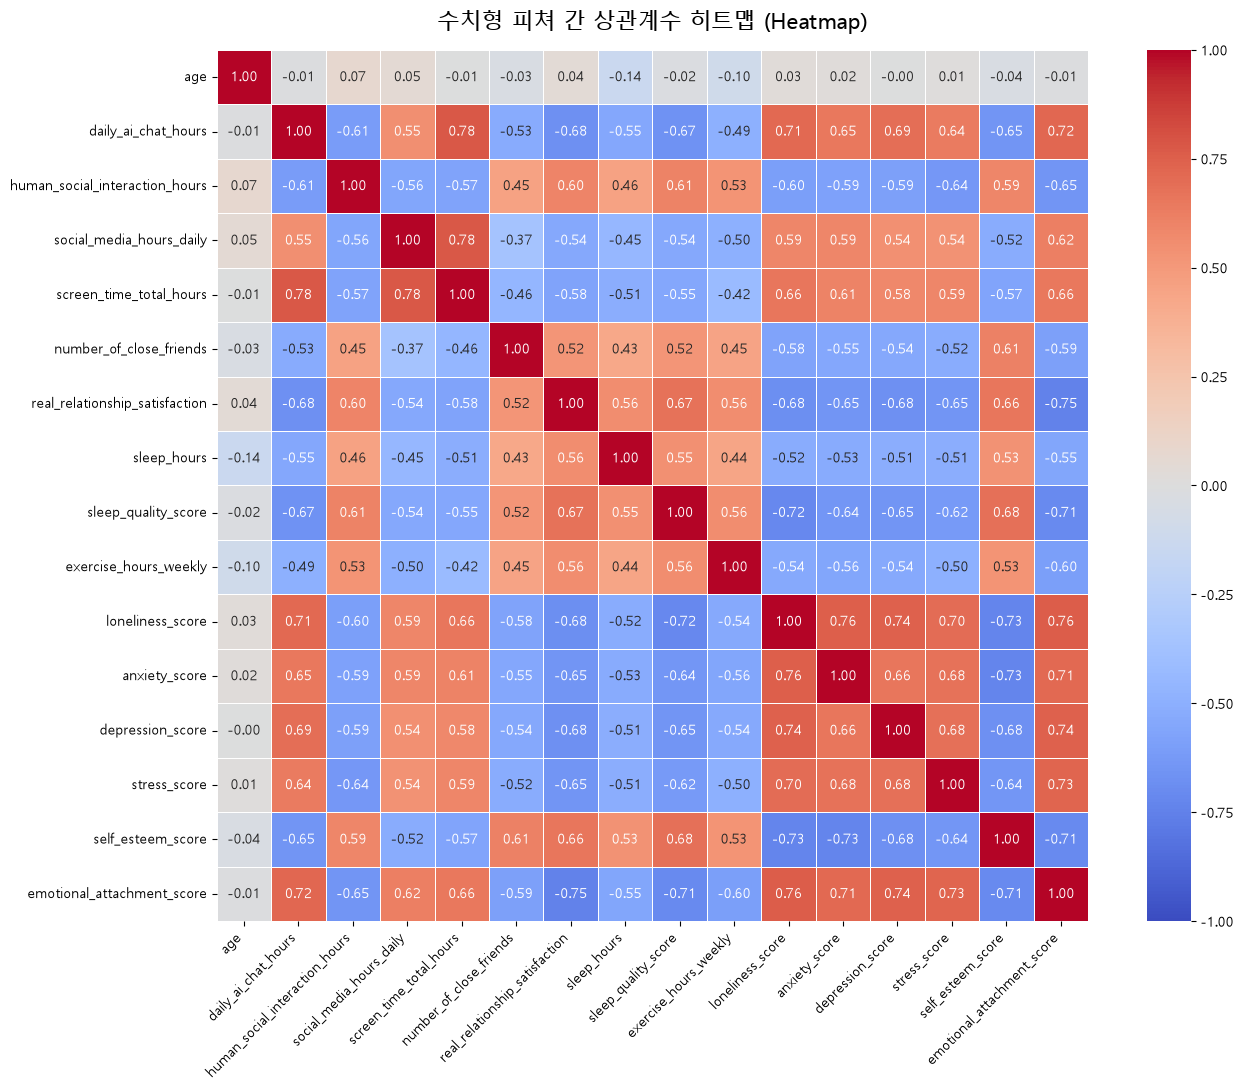

In [ ]:
# ===========================================================================================================

# EDA: 상관계수 히트맵 활용

# ===========================================================================================================

# 수치형 피처만 추출하여 상관계수 계산 / 추후 범주형 피쳐 중 숫자로 변경할 수 있는 피쳐가 있으면 포함 고려 
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 히트맵 시각화
plt.figure(figsize=(14,11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('수치형 피쳐 간 상관계수 히트맵 (Heatmap)', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

산점도 분석 대상 상위 6개 피처:
  1위: loneliness_score (상관계수 r = +0.760)
  2위: real_relationship_satisfaction (상관계수 r = -0.747)
  3위: depression_score (상관계수 r = +0.743)
  4위: stress_score (상관계수 r = +0.728)
  5위: daily_ai_chat_hours (상관계수 r = +0.719)
  6위: anxiety_score (상관계수 r = +0.712)


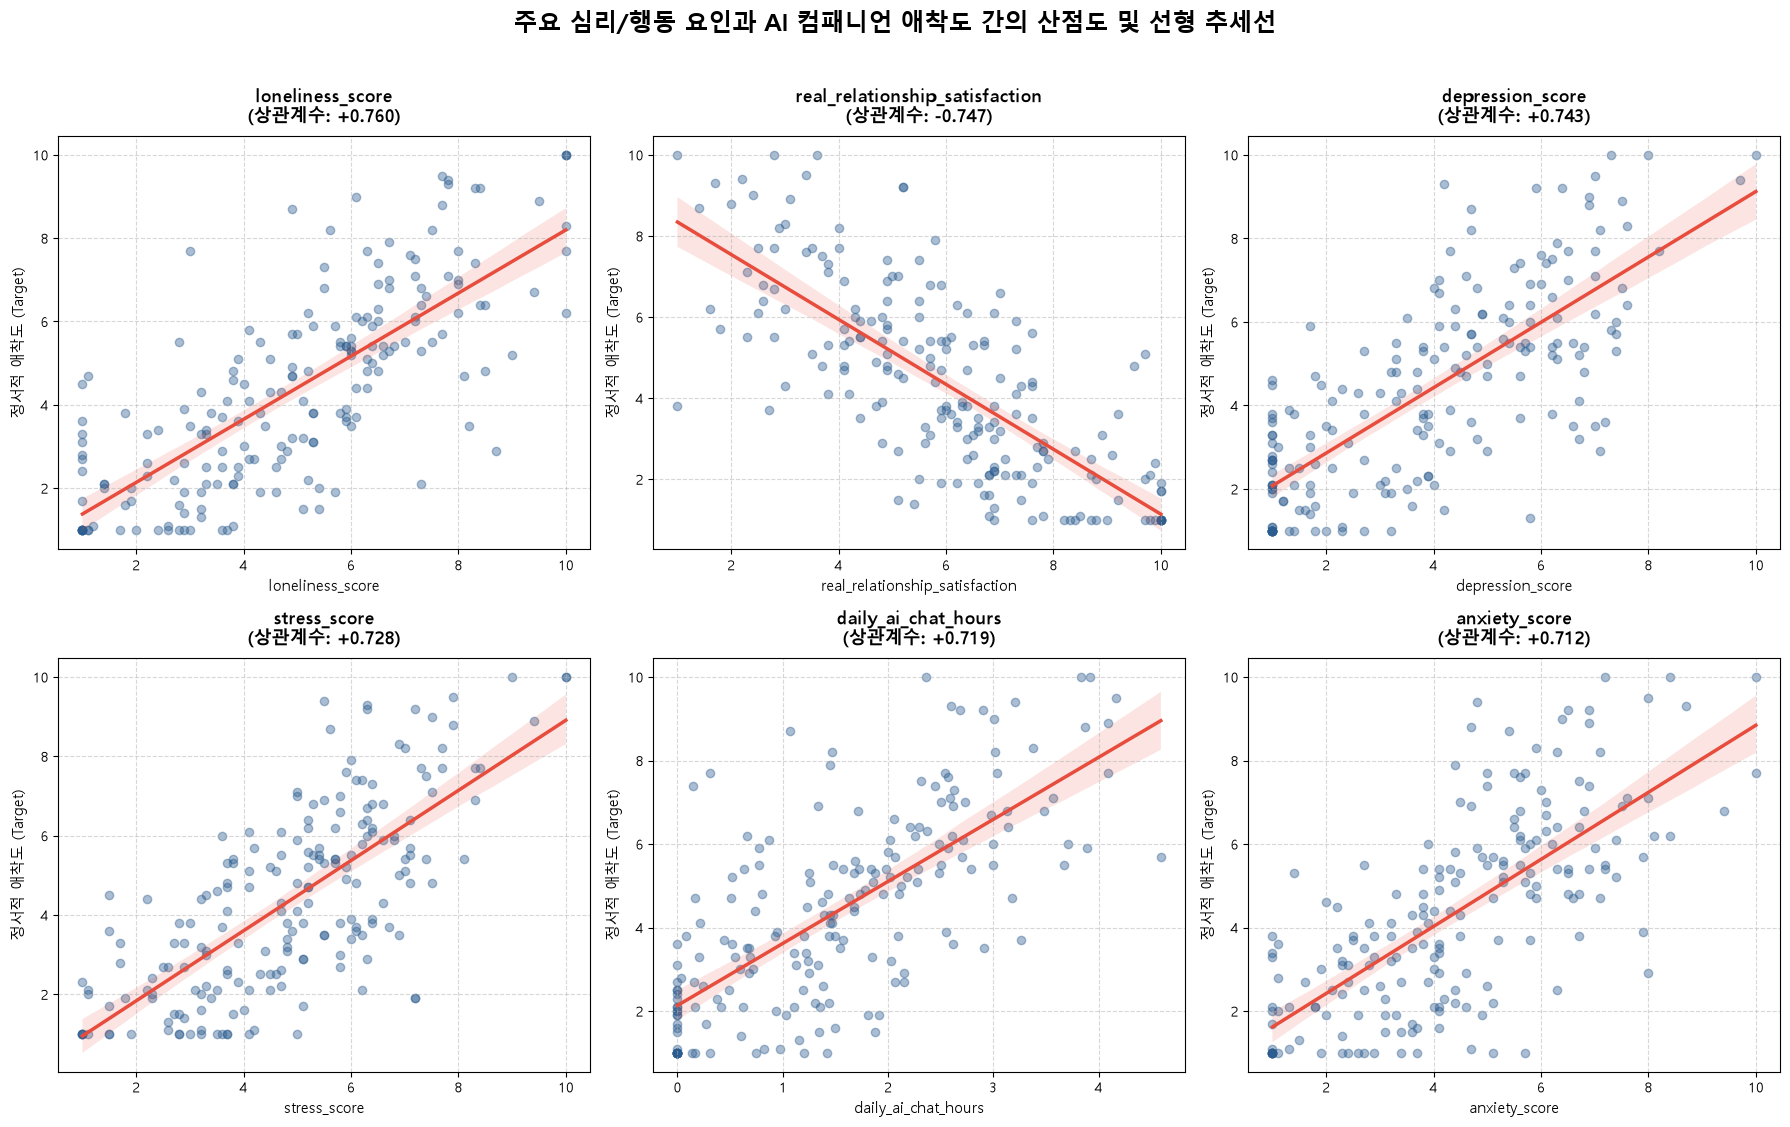

In [16]:
# ===========================================================================================================

# EDA: 종속 변수 vs 주요 독립 변수 산점도 및 선형 추세선 시각화

# ===========================================================================================================

# 상관계수 기준 종속 변수와의 상관관계 절댓값이 큰 상위 6개 피쳐 자동 선정
numeric_df = df.select_dtypes(include=[np.number])
corr_series = numeric_df.corr()['emotional_attachment_score'].drop('emotional_attachment_score')
top_6_features = corr_series.abs().sort_values(ascending=False).head(6).index.tolist()

print("산점도 분석 대상 상위 6개 피처:")
for rank, feat in enumerate(top_6_features, 1):
    print(f"  {rank}위: {feat} (상관계수 r = {corr_series[feat]:+.3f})")

# 2. 2행 3열 서브플롯(Subplots) 생성
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for idx, feature in enumerate(top_6_features):
    corr_val = corr_series[feature]
    
    # seaborn의 regplot으로 산점도 + 선형 회귀 추세선 동시 시각화
    sns.regplot(
        data=df,
        x=feature,
        y='emotional_attachment_score',
        ax=axes[idx],
        scatter_kws={'alpha': 0.4, 'color': '#2b5c8f'}, # 점 투명도 및 색상
        line_kws={'color': '#e74c3c', 'linewidth': 2.5}  # 회귀선 색상 및 두께
    )
    
    # 그래프 서식 설정
    axes[idx].set_title(f'{feature}\n(상관계수: {corr_val:+.3f})', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('정서적 애착도 (Target)', fontsize=11)
    axes[idx].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('주요 심리/행동 요인과 AI 컴패니언 애착도 간의 산점도 및 선형 추세선', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
